# Manuscript 2 — Figure 4b, 4c and Figure S7a–c
### Neuron-by-neuron connectivity, path overlap, and cell-type block statistics

All panels here are derived from **two neuron × neuron matrices that ship with this
repository**, so no CAVE query is required:

| File | Contents |
| --- | --- |
| `data/adjacency_overlap/adjacency_matrix.csv` | synapse counts, presynaptic (rows) × postsynaptic (cols) |
| `data/adjacency_overlap/overlap_matrix.csv` | axon–dendrite path overlap in µm, same axes |
| `data/adjacency_overlap/tag_of.csv` | `pt_root_id → tag` (cell type) for every neuron in the two matrices |

`tag_of.csv` was produced by tagging every ID in the two matrices with its cell type from
the CAVE table `spinalcord_neuron_clusters_2`, remapping stale root IDs through
`chunkedgraph.get_latest_roots` first. That step is reproduced in section 1b below but is
**commented out** — the resulting table is shipped, so the notebook runs offline.

**Panels produced**

| Panel | Matrix | Colour cap |
| --- | --- | --- |
| **Fig. 4b** | synapse count | 95th percentile of non-zero entries (= 8) |
| **Fig. 4c** | normalized synapse density, synapses per 10 µm of overlap | 95th percentile (= 0.806) |
| **Fig. S7a** | axon–dendrite path overlap (µm) | 99th percentile (= 879) |
| **Fig. S7b** | cell-type block: connection probability among overlapping pairs | — |
| **Fig. S7c** | cell-type block: mean synapses per overlapping pair | — |

## 0) Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/adjacency_overlap")
OUT_DIR = Path("figure4_outputs")
OUT_DIR.mkdir(exist_ok=True)

## 1) Load the matrices and the cell-type tags

In [2]:
adjacency_df = pd.read_csv(DATA_DIR / "adjacency_matrix.csv", index_col=0)
overlap_df = pd.read_csv(DATA_DIR / "overlap_matrix.csv", index_col=0)

# keep IDs as strings everywhere to avoid int/float/str join mismatches
for X in (adjacency_df, overlap_df):
    X.index = X.index.astype(str)
    X.columns = X.columns.astype(str)

tag_of = pd.read_csv(DATA_DIR / "tag_of.csv", index_col=0)["tag"]
tag_of.index = tag_of.index.astype(str)
tag_of = tag_of.astype(str).str.strip()

print("adjacency_matrix.csv:", adjacency_df.shape)
print("overlap_matrix.csv:  ", overlap_df.shape)
print(f"{len(tag_of)} tagged neurons")
print(tag_of.value_counts().to_string())

adjacency_matrix.csv: (177, 223)
overlap_matrix.csv:   (177, 223)
223 tagged neurons
tag
v1               41
v2               36
np_module        27
cltmr_module     24
r                24
p2_noci          16
adltmr_module    15
p2_poly          15
noci_module      10
p2_cold           9
p1                6


### 1b) How `tag_of.csv` was built (not run)

Root IDs in the two matrices predate later proofreading edits, so some of them are no longer
present in `spinalcord_neuron_clusters_2`. For any ID not found directly we ask
`chunkedgraph.get_latest_roots` for its current segment ID(s) and use whichever of those *is*
in the tag table; IDs that resolve to zero or to more than one tagged segment are dropped.

Un-comment and run this only if you want to re-tag against a newer materialization.

In [3]:
# import caveclient
# from tqdm import tqdm
#
# client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr")
#
# cell_tag = client.materialize.query_table("spinalcord_neuron_clusters_2")
# cell_tag = cell_tag[["pt_root_id", "tag"]].dropna()
# cell_tag["pt_root_id"] = cell_tag["pt_root_id"].astype(str).str.strip()
# # strip whitespace so e.g. "noci_module " doesn't silently fail to match SENSORY_MODULES
# cell_tag["tag"] = cell_tag["tag"].astype(str).str.strip()
#
# # a neuron can appear more than once (re-tagging); keep the most frequent tag per ID
# id_to_tag = cell_tag.groupby("pt_root_id")["tag"].agg(lambda s: s.value_counts().index[0])
# cave_tagged_ids = set(id_to_tag.index)
#
# all_ids = sorted(set(adjacency_df.index) | set(adjacency_df.columns)
#                  | set(overlap_df.index) | set(overlap_df.columns))
# outdated_ids = [i for i in all_ids if i not in cave_tagged_ids]
#
# resolved_tag = dict(id_to_tag)
# unresolved = []
# for old_id in tqdm(outdated_ids, desc="Resolving latest root ids"):
#     try:
#         latest_roots = [str(int(r)) for r in client.chunkedgraph.get_latest_roots(int(old_id))]
#     except Exception as e:
#         unresolved.append((old_id, f"chunkedgraph error: {e}"))
#         continue
#     hits = [r for r in latest_roots if r in cave_tagged_ids]
#     if len(hits) == 1:
#         resolved_tag[old_id] = id_to_tag[hits[0]]
#     else:
#         unresolved.append((old_id, f"{len(hits)} latest roots in tag table: {hits}"))
#
# tag_of = pd.Series(resolved_tag, name="tag")
# tag_of.index.name = "pt_root_id"
# tag_of.to_csv(DATA_DIR / "tag_of.csv", header=True)
# print(f"resolved {len(outdated_ids) - len(unresolved)}, unresolved {len(unresolved)}")

## 2) Cluster order, display labels, and the sensory "yellow zone"

The four sensory modules plus `r` (radial) form one contiguous block on each axis. Any
boundary line touching a sensory-module tag is drawn **orange** for the portion of its length
that crosses the sensory block on the *other* axis, and red elsewhere. `r`'s own band is
deliberately excluded from that extent, so the `r`-adjacent boundary stays red across it.

In [4]:
POST_CLUSTER_ORDER = [
    "p1", "p2_cold", "p2_noci", "p2_poly", "v1", "v2", "r",
    "noci_module", "np_module", "cltmr_module", "adltmr_module",
]
PRE_CLUSTER_ORDER = [
    "noci_module", "np_module", "cltmr_module", "adltmr_module", "r", "v1", "v2",
]
SENSORY_MODULES = {"noci_module", "np_module", "cltmr_module", "adltmr_module"}

LABEL_MAP = {
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

def display_label(tag):
    return LABEL_MAP.get(tag, tag)

## 3) Orient the matrices to presynaptic (rows) × postsynaptic (cols)

Determined from tag membership rather than assumed, so this still works if the CSVs are ever
regenerated with the opposite orientation.

In [5]:
adjacency_df = adjacency_df.loc[
    adjacency_df.index.isin(tag_of.index), adjacency_df.columns.isin(tag_of.index)
]
overlap_df = overlap_df.loc[
    overlap_df.index.isin(tag_of.index), overlap_df.columns.isin(tag_of.index)
]

pre_tag_ids = set(tag_of[tag_of.isin(PRE_CLUSTER_ORDER)].index)
post_tag_ids = set(tag_of[tag_of.isin(POST_CLUSTER_ORDER)].index)

def orient_pre_rows_post_cols(df):
    row_in_pre = sum(i in pre_tag_ids for i in df.index)
    col_in_post = sum(j in post_tag_ids for j in df.columns)
    row_in_post = sum(i in post_tag_ids for i in df.index)
    col_in_pre = sum(j in pre_tag_ids for j in df.columns)
    return df.T if (row_in_post + col_in_pre) > (row_in_pre + col_in_post) else df

adjacency_df = orient_pre_rows_post_cols(adjacency_df).apply(pd.to_numeric, errors="coerce").fillna(0.0)
overlap_df = orient_pre_rows_post_cols(overlap_df).apply(pd.to_numeric, errors="coerce").fillna(0.0)
overlap_df = overlap_df.reindex(index=adjacency_df.index, columns=adjacency_df.columns, fill_value=0.0)

# for plotting: rows = postsynaptic, cols = presynaptic
A = adjacency_df.T
O = overlap_df.T

print("presynaptic × postsynaptic:", adjacency_df.shape)

presynaptic × postsynaptic: (177, 223)


## 4) Sort neurons by cell type and locate the category boundaries

In [6]:
def ordered_categorical(tags, order):
    cats, seen = [], set()
    for c in list(order) + list(tags.unique()):
        if c not in seen:
            cats.append(c); seen.add(c)
    return pd.Categorical(tags, categories=cats, ordered=True)


def sort_ids_by_tag(ids, order):
    """Sort ids by tag (in `order`, unseen tags appended at the end). Returns the
    sorted id list, group labels in order, tick centers, and each group's
    (start, end) index range (end exclusive)."""
    ids = pd.Index(ids).astype(str)
    tags = tag_of.reindex(ids).fillna("unknown")
    order_df = (
        pd.DataFrame({"id": ids, "tag": ordered_categorical(tags, order)})
        .sort_values(["tag", "id"], kind="mergesort")
        .reset_index(drop=True)
    )
    sorted_ids = order_df["id"].tolist()
    starts, ends, labels = [], [], []
    for tag, grp in order_df.groupby("tag", sort=False, observed=True):
        starts.append(grp.index[0]); ends.append(grp.index[-1] + 1); labels.append(str(tag))
    centers = [(s + e - 1) / 2.0 for s, e in zip(starts, ends)]
    return sorted_ids, labels, centers, list(zip(starts, ends))


def group_extent(labels, group_bounds, tags):
    """(start, end) pixel edges spanning the union of groups whose label is in `tags`
    (must be contiguous in the cluster order), or None if none are present."""
    idxs = [i for i, l in enumerate(labels) if l in tags]
    if not idxs:
        return None
    return group_bounds[idxs[0]][0] - 0.5, group_bounds[idxs[-1]][1] - 0.5


def category_boundaries(labels, group_bounds):
    """Positions between consecutive groups, flagged True where at least one side is a
    sensory module (those lines get the orange sub-segment)."""
    return [
        (group_bounds[i][1] - 0.5,
         labels[i] in SENSORY_MODULES or labels[i + 1] in SENSORY_MODULES)
        for i in range(len(labels) - 1)
    ]


row_sorted, row_labels, row_centers, row_group_bounds = sort_ids_by_tag(A.index, POST_CLUSTER_ORDER)
col_sorted, col_labels, col_centers, col_group_bounds = sort_ids_by_tag(A.columns, PRE_CLUSTER_ORDER)

A_sorted = A.reindex(index=row_sorted, columns=col_sorted).fillna(0.0)
O_sorted = O.reindex(index=row_sorted, columns=col_sorted).fillna(0.0)

row_boundaries = category_boundaries(row_labels, row_group_bounds)   # horizontal lines
col_boundaries = category_boundaries(col_labels, col_group_bounds)   # vertical lines

# A horizontal (row) boundary is split using an extent from the COLUMN axis, and vice versa.
col_sensory_extent = group_extent(col_labels, col_group_bounds, SENSORY_MODULES)
row_sensory_extent = group_extent(row_labels, row_group_bounds, SENSORY_MODULES)

print("Row (postsynaptic) groups:", [(l, int(e - s)) for l, (s, e) in zip(row_labels, row_group_bounds)])
print("Col (presynaptic) groups: ", [(l, int(e - s)) for l, (s, e) in zip(col_labels, col_group_bounds)])

Row (postsynaptic) groups: [('p1', 6), ('p2_cold', 9), ('p2_noci', 16), ('p2_poly', 15), ('v1', 41), ('v2', 36), ('r', 24), ('noci_module', 10), ('np_module', 27), ('cltmr_module', 24), ('adltmr_module', 15)]
Col (presynaptic) groups:  [('noci_module', 10), ('np_module', 27), ('cltmr_module', 24), ('adltmr_module', 15), ('r', 24), ('v1', 41), ('v2', 36)]


## 5) Plotting helper

Only the heatmap grid itself is rasterized (`rasterized=True`) — with hundreds of rows and
columns, vectorizing every cell is what forced these panels to be saved as PNG before. The
dashed separators, tick labels and colorbar stay as vector SVG, so they remain crisp and the
file stays small.

In [7]:
CM = 1 / 2.54
FIGSIZE_CM = (6, 6)
TICK_FONTSIZE = 4
CBAR_FONTSIZE = 5


def draw_split_hline(ax, y, full_x, sensory_range, linewidth=0.3):
    """Horizontal boundary: orange where it crosses `sensory_range` (a column extent),
    red for the rest of its length. Pass sensory_range=None for plain red."""
    x0, x1 = full_x
    if sensory_range is None:
        ax.hlines(y, x0, x1, colors="red", linestyles="--", linewidth=linewidth)
        return
    sx0, sx1 = sensory_range
    ax.hlines(y, sx0, sx1, colors="orange", linestyles="--", linewidth=linewidth)
    if sx0 > x0:
        ax.hlines(y, x0, sx0, colors="red", linestyles="--", linewidth=linewidth)
    if sx1 < x1:
        ax.hlines(y, sx1, x1, colors="red", linestyles="--", linewidth=linewidth)


def draw_split_vline(ax, x, full_y, sensory_range, linewidth=0.3):
    """Vertical counterpart of draw_split_hline; `sensory_range` is a row extent."""
    y0, y1 = full_y
    if sensory_range is None:
        ax.vlines(x, y0, y1, colors="red", linestyles="--", linewidth=linewidth)
        return
    sy0, sy1 = sensory_range
    ax.vlines(x, sy0, sy1, colors="orange", linestyles="--", linewidth=linewidth)
    if sy0 > y0:
        ax.vlines(x, y0, sy0, colors="red", linestyles="--", linewidth=linewidth)
    if sy1 < y1:
        ax.vlines(x, sy1, y1, colors="red", linestyles="--", linewidth=linewidth)


def plot_tagged_heatmap(matrix, *, cbar_label, out_path, cap_percentile=95,
                        cmap="Blues", raster_dpi=600, figsize=None):
    """Neuron-level heatmap. vmax is the given percentile of the NON-ZERO entries."""
    if figsize is None:
        figsize = (FIGSIZE_CM[0] * CM, FIGSIZE_CM[1] * CM)

    vals = matrix.to_numpy(dtype=float)
    pos = vals[np.isfinite(vals) & (vals > 0)]
    vmax = float(np.percentile(pos, cap_percentile)) if pos.size else 1.0

    n_rows, n_cols = matrix.shape
    full_y, full_x = (-0.5, n_rows - 0.5), (-0.5, n_cols - 0.5)

    mpl.rcParams.update({"font.size": TICK_FONTSIZE})
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(np.clip(vals, 0, vmax), aspect="auto", cmap=cmap,
                   vmin=0, vmax=vmax, interpolation="nearest", rasterized=True)

    ax.set_xticks(col_centers)
    ax.set_xticklabels([display_label(l) for l in col_labels],
                       rotation=-45, ha="left", fontsize=TICK_FONTSIZE)
    ax.set_yticks(row_centers)
    ax.set_yticklabels([display_label(l) for l in row_labels], fontsize=TICK_FONTSIZE)
    ax.set_xlabel("Presynaptic")
    ax.set_ylabel("Postsynaptic")

    for pos_, is_sensory in row_boundaries:
        draw_split_hline(ax, pos_, full_x, col_sensory_extent if is_sensory else None)
    for pos_, is_sensory in col_boundaries:
        draw_split_vline(ax, pos_, full_y, row_sensory_extent if is_sensory else None)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f"{cbar_label} (capped at {cap_percentile}%: {vmax:.3g})", fontsize=CBAR_FONTSIZE)
    cbar.ax.tick_params(labelsize=TICK_FONTSIZE)

    plt.tight_layout()
    fig.savefig(out_path, format="svg", dpi=raster_dpi, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path, f"| vmax = {vmax:.4g}")
    return vmax

## Figure 4b — synapse count matrix

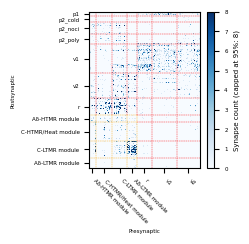

Saved: figure4_outputs/figure4b_synapse_count_matrix.svg | vmax = 8


In [8]:
vmax_4b = plot_tagged_heatmap(
    A_sorted,
    cbar_label="Synapse count",
    out_path=OUT_DIR / "figure4b_synapse_count_matrix.svg",
    cap_percentile=95,
)
assert np.isclose(vmax_4b, 8.0), vmax_4b  # published colorbar tops out at 8

## Figure 4c — normalized synapse density

Synapses per **10 µm** of axon–dendrite path overlap. Only defined where the two neurons
actually overlap; pairs with zero overlap are set to 0 rather than NaN so they render at the
bottom of the colormap (and are excluded from the percentile, which uses non-zero entries only).

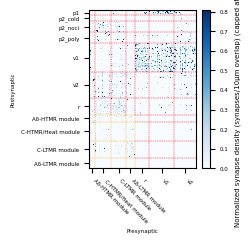

Saved: figure4_outputs/figure4c_synapse_density_matrix.svg | vmax = 0.8057


In [9]:
OVERLAP_UNIT_UM = 10.0  # report density per 10 µm of overlap, as in the published panel

O_vals = O_sorted.to_numpy(dtype=float)
with np.errstate(divide="ignore", invalid="ignore"):
    density_vals = np.divide(
        A_sorted.to_numpy(dtype=float), O_vals / OVERLAP_UNIT_UM,
        out=np.zeros(A_sorted.shape, dtype=float),
        where=(O_vals > 0),
    )
density_df = pd.DataFrame(density_vals, index=A_sorted.index, columns=A_sorted.columns)

vmax_4c = plot_tagged_heatmap(
    density_df,
    cbar_label="Normalized synapse density (synapses/10µm overlap)",
    out_path=OUT_DIR / "figure4c_synapse_density_matrix.svg",
    cap_percentile=95,
)
assert np.isclose(vmax_4c, 0.8, atol=0.01), vmax_4c  # published colorbar tops out at 0.8

## Figure S7a — axon–dendrite path overlap matrix

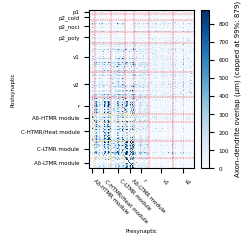

Saved: figure4_outputs/figureS7a_path_overlap_matrix.svg | vmax = 878.6


In [10]:
vmax_S7a = plot_tagged_heatmap(
    O_sorted,
    cbar_label="Axon–dendrite overlap (µm)",
    out_path=OUT_DIR / "figureS7a_path_overlap_matrix.svg",
    cap_percentile=99,
)
assert np.isclose(round(vmax_S7a), 879), vmax_S7a  # published colorbar note: "capped at P99: 879"

## Figure S7b, S7c — cell-type block statistics

Collapse the neuron-level matrices to one cell per (presynaptic cell type, postsynaptic cell
type). Both statistics are computed over the **anatomically overlapping pairs only** — every
ordered neuron pair in that block with `overlap > 0`:

- **S7b, connection probability** — fraction of those pairs that also have ≥1 synapse.
- **S7c, mean synapses per overlapping pair** — mean synapse count over those same pairs
  (so pairs that overlap but are unconnected contribute a 0).

A neuron's pair with itself is *not* excluded from the within-type blocks; the diagonal of a
`v1 → v1` block is included exactly as in the original analysis.

In [11]:
pre_tag_series = tag_of.reindex(adjacency_df.index)
post_tag_series = tag_of.reindex(adjacency_df.columns)

ids_by_pre_ct = {t: pre_tag_series.index[pre_tag_series == t].tolist() for t in PRE_CLUSTER_ORDER}
ids_by_post_ct = {t: post_tag_series.index[post_tag_series == t].tolist() for t in POST_CLUSTER_ORDER}

connected_rate_df = pd.DataFrame(np.nan, index=PRE_CLUSTER_ORDER, columns=POST_CLUSTER_ORDER, dtype=float)
mean_syn_df = pd.DataFrame(np.nan, index=PRE_CLUSTER_ORDER, columns=POST_CLUSTER_ORDER, dtype=float)
n_overlap_pairs_df = pd.DataFrame(0, index=PRE_CLUSTER_ORDER, columns=POST_CLUSTER_ORDER, dtype=int)
n_syn_pairs_df = pd.DataFrame(0, index=PRE_CLUSTER_ORDER, columns=POST_CLUSTER_ORDER, dtype=int)

for pre_type in PRE_CLUSTER_ORDER:
    rows = ids_by_pre_ct[pre_type]
    for post_type in POST_CLUSTER_ORDER:
        cols = ids_by_post_ct[post_type]
        if not rows or not cols:
            continue

        blockA = adjacency_df.loc[rows, cols].to_numpy(dtype=float)
        blockO = overlap_df.loc[rows, cols].to_numpy(dtype=float)

        overlap_mask = np.isfinite(blockO) & (blockO > 0)
        n_overlap = int(overlap_mask.sum())
        if n_overlap == 0:
            continue
        syn_mask = np.isfinite(blockA) & (blockA > 0)

        n_overlap_pairs_df.loc[pre_type, post_type] = n_overlap
        n_syn_pairs_df.loc[pre_type, post_type] = int((overlap_mask & syn_mask).sum())
        connected_rate_df.loc[pre_type, post_type] = (overlap_mask & syn_mask).sum() / n_overlap
        mean_syn_df.loc[pre_type, post_type] = blockA[overlap_mask].mean()

print("Connection probability (rows = presynaptic, cols = postsynaptic):")
print(connected_rate_df.round(3).to_string())
print("\nNumber of overlapping pairs per block:")
print(n_overlap_pairs_df.to_string())

Connection probability (rows = presynaptic, cols = postsynaptic):
                  p1  p2_cold  p2_noci  p2_poly     v1     v2      r  noci_module  np_module  cltmr_module  adltmr_module
noci_module    0.028    0.167    0.137    0.080  0.050  0.243  0.207        0.104      0.014         0.040          0.000
np_module      0.000    0.012    0.267    0.240  0.046  0.162  0.340        0.155      0.129         0.063          0.004
cltmr_module   0.038    0.000    0.141    0.164  0.267  0.377  0.406        0.151      0.048         0.158          0.007
adltmr_module  0.000    0.125    0.029    0.069  0.147  0.272  0.113        0.133      0.151         0.582          0.049
r              0.469    0.000    0.009    0.058  0.599  0.072  0.063        0.019      0.006         0.029          0.004
v1             0.723    0.000    0.006    0.032  0.426  0.073  0.056        0.006      0.004         0.008          0.004
v2             0.184    0.068    0.059    0.167  0.420  0.127  0.048        0.01

### Cross-check against the values quoted in the Results text

In [12]:
# (pre, post, connection probability, mean synapses per overlapping pair)
PUBLISHED = [
    ("v1",           "p1",       0.727, 2.01),
    ("v1",           "v1",       0.428, 0.91),
    ("r",            "v1",       0.600, 1.51),
    ("v2",           "v1",       0.420, 1.21),
    ("cltmr_module", "p2_poly",  0.160, 0.36),
    ("np_module",    "p2_poly",  0.240, 0.42),
    ("v2",           "p2_poly",  0.170, 0.31),
    ("np_module",    "p2_noci",  0.270, 0.44),
]

print(f"{'pre':>14s} -> {'post':<10s} {'p(conn)':>18s} {'syn/pair':>18s}")
for pre, post, p_pub, s_pub in PUBLISHED:
    p_mine = connected_rate_df.loc[pre, post]
    s_mine = mean_syn_df.loc[pre, post]
    flag = "" if (abs(p_mine - p_pub) < 0.005 and abs(s_mine - s_pub) < 0.005) else "  <-- check"
    print(f"{pre:>14s} -> {post:<10s} {p_mine:7.3f} (pub {p_pub:.3f}) {s_mine:7.2f} (pub {s_pub:.2f}){flag}")

           pre -> post                  p(conn)           syn/pair
            v1 -> p1           0.723 (pub 0.727)    2.01 (pub 2.01)
            v1 -> v1           0.426 (pub 0.428)    0.91 (pub 0.91)
             r -> v1           0.599 (pub 0.600)    1.51 (pub 1.51)
            v2 -> v1           0.420 (pub 0.420)    1.21 (pub 1.21)
  cltmr_module -> p2_poly      0.164 (pub 0.160)    0.36 (pub 0.36)
     np_module -> p2_poly      0.240 (pub 0.240)    0.43 (pub 0.42)  <-- check
            v2 -> p2_poly      0.167 (pub 0.170)    0.31 (pub 0.31)
     np_module -> p2_noci      0.267 (pub 0.270)    0.44 (pub 0.44)


In [13]:
block_row_labels = POST_CLUSTER_ORDER
block_col_labels = PRE_CLUSTER_ORDER
block_row_bounds = [(i, i + 1) for i in range(len(block_row_labels))]
block_col_bounds = [(i, i + 1) for i in range(len(block_col_labels))]

block_row_boundaries = category_boundaries(block_row_labels, block_row_bounds)
block_col_boundaries = category_boundaries(block_col_labels, block_col_bounds)
block_col_sensory_extent = group_extent(block_col_labels, block_col_bounds, SENSORY_MODULES)
block_row_sensory_extent = group_extent(block_row_labels, block_row_bounds, SENSORY_MODULES)


def plot_block_matrix(block_df, *, cbar_label, out_path, annotate_fmt="{:.2f}",
                      cmap="Blues", raster_dpi=600, figsize=None):
    """Cell-type × cell-type block heatmap with the value printed in each cell.
    `block_df` is presynaptic (rows) × postsynaptic (cols); it is transposed for
    plotting so the axes match the neuron-level panels."""
    if figsize is None:
        figsize = (FIGSIZE_CM[0] * CM, FIGSIZE_CM[1] * CM)

    plot_df = block_df.T.reindex(index=block_row_labels, columns=block_col_labels)
    vals = plot_df.to_numpy(dtype=float)
    vmax = float(np.nanmax(vals)) if np.isfinite(vals).any() else 1.0

    n_rows, n_cols = plot_df.shape
    full_y, full_x = (-0.5, n_rows - 0.5), (-0.5, n_cols - 0.5)

    mpl.rcParams.update({"font.size": TICK_FONTSIZE})
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(vals, aspect="auto", cmap=cmap, vmin=0, vmax=vmax, interpolation="nearest")

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([display_label(l) for l in block_col_labels],
                       rotation=-45, ha="left", fontsize=TICK_FONTSIZE)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([display_label(l) for l in block_row_labels], fontsize=TICK_FONTSIZE)
    ax.set_xlabel("Presynaptic")
    ax.set_ylabel("Postsynaptic")

    for pos_, is_sensory in block_row_boundaries:
        draw_split_hline(ax, pos_, full_x, block_col_sensory_extent if is_sensory else None)
    for pos_, is_sensory in block_col_boundaries:
        draw_split_vline(ax, pos_, full_y, block_row_sensory_extent if is_sensory else None)

    for i in range(n_rows):
        for j in range(n_cols):
            if not np.isfinite(vals[i, j]):
                continue
            ax.text(j, i, annotate_fmt.format(vals[i, j]), ha="center", va="center",
                    fontsize=TICK_FONTSIZE,
                    color="white" if vals[i, j] > 0.6 * vmax else "black")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(cbar_label, fontsize=CBAR_FONTSIZE)
    cbar.ax.tick_params(labelsize=TICK_FONTSIZE)

    plt.tight_layout()
    fig.savefig(out_path, format="svg", dpi=raster_dpi, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)
    return vmax

### Figure S7b — connection probability

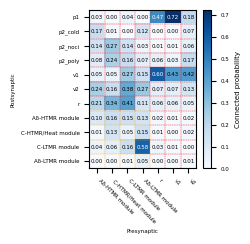

Saved: figure4_outputs/figureS7b_connection_probability.svg


0.7225130890052356

In [14]:
plot_block_matrix(
    connected_rate_df,
    cbar_label="Connected probability",
    out_path=OUT_DIR / "figureS7b_connection_probability.svg",
)

### Figure S7c — mean synapses per overlapping pair

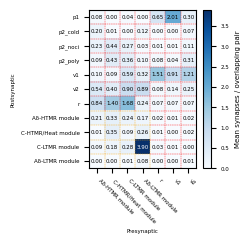

Saved: figure4_outputs/figureS7c_mean_synapses_per_overlapping_pair.svg


3.9019607843137254

In [15]:
plot_block_matrix(
    mean_syn_df,
    cbar_label="Mean synapses / overlapping pair",
    out_path=OUT_DIR / "figureS7c_mean_synapses_per_overlapping_pair.svg",
)

### Save the block tables

In [16]:
connected_rate_df.to_csv(OUT_DIR / "celltype_connection_probability.csv")
mean_syn_df.to_csv(OUT_DIR / "celltype_mean_synapses_per_overlapping_pair.csv")
n_overlap_pairs_df.to_csv(OUT_DIR / "celltype_n_overlapping_pairs.csv")
n_syn_pairs_df.to_csv(OUT_DIR / "celltype_n_connected_overlapping_pairs.csv")
print("Saved block tables to", OUT_DIR)

Saved block tables to figure4_outputs


## Figure 4f — cell-type bubble grid

Each bubble is one (presynaptic cell type -> postsynaptic cell type) block:

- **area** = average synapses per *overlapping* pair, i.e. all synapses in the block divided
  by the number of pairs with `overlap > 0`. Note the numerator is the block's **total**
  synapse count, so the handful of synapses between pairs whose skeletons register zero path
  overlap are included; this is what makes it differ slightly from the S7c matrix above.
  Bubble area is scaled against the largest block value (3.90, `v1 -> p1`); the size legend
  is labelled at 0.25 / 0.5 / 1 / 2 rather than at that maximum.
- **colour** = mean synapse density over the same overlapping pairs, in synapses per 10 µm
  (the colorbar formatter multiplies the per-µm values by 10).

In [17]:
from matplotlib.ticker import FuncFormatter

pre_order = PRE_CLUSTER_ORDER
post_order = POST_CLUSTER_ORDER

# density over overlapping pairs only (synapses / µm), and average synapses per overlapping pair
D_overlaponly_avg = pd.DataFrame(np.nan, index=pre_order, columns=post_order, dtype=float)
A_overlappairs_avg = pd.DataFrame(np.nan, index=pre_order, columns=post_order, dtype=float)

for g in pre_order:
    rows = ids_by_pre_ct[g]
    for c in post_order:
        cols = ids_by_post_ct[c]
        if not rows or not cols:
            continue

        blockA = adjacency_df.loc[rows, cols].to_numpy(dtype=float)
        blockO = overlap_df.loc[rows, cols].to_numpy(dtype=float)

        overlap_mask = np.isfinite(blockO) & (blockO > 0)
        n_overlap_pairs = int(overlap_mask.sum())
        total_syn = float(np.nansum(np.where(np.isfinite(blockA), blockA, 0.0)))

        with np.errstate(divide="ignore", invalid="ignore"):
            dens = np.divide(blockA, blockO, where=overlap_mask)
        dens = np.where(overlap_mask & np.isfinite(dens), dens, np.nan)
        if np.isfinite(dens).any():
            D_overlaponly_avg.loc[g, c] = np.nanmean(dens)

        if n_overlap_pairs > 0:
            A_overlappairs_avg.loc[g, c] = total_syn / n_overlap_pairs

print("Avg synapses per overlapping pair (rows = presynaptic):")
print(A_overlappairs_avg.round(2).to_string())

Avg synapses per overlapping pair (rows = presynaptic):
                 p1  p2_cold  p2_noci  p2_poly    v1    v2     r  noci_module  np_module  cltmr_module  adltmr_module
noci_module    0.11     0.20     0.26     0.11  0.10  0.55  0.84         0.21       0.02          0.09           0.00
np_module      0.00     0.01     0.45     0.43  0.09  0.40  1.40         0.33       0.35          0.18           0.00
cltmr_module   0.04     0.00     0.27     0.36  0.59  0.90  1.68         0.24       0.09          0.28           0.01
adltmr_module  0.00     0.12     0.03     0.10  0.32  0.89  0.24         0.17       0.26          3.90           0.08
r              0.66     0.00     0.01     0.08  1.51  0.08  0.07         0.02       0.01          0.04           0.00
v1             2.01     0.00     0.01     0.04  0.91  0.14  0.08         0.01       0.00          0.01           0.00
v2             0.30     0.08     0.11     0.31  1.22  0.27  0.08         0.02       0.03          0.00           0.01


In [18]:
def _area_scaled_sizes(vals, max_area_pts2=400.0, size_vmax=None):
    """Marker AREA (matplotlib `s`) proportional to value, so a bubble twice the
    value has twice the ink, not twice the diameter."""
    vals = np.asarray(vals, float)
    if size_vmax is None:
        size_vmax = np.nanmax(vals) if np.any(np.isfinite(vals)) else 0.0
    if not np.isfinite(size_vmax) or size_vmax <= 0:
        return np.zeros_like(vals)
    return (vals / size_vmax) * max_area_pts2


def _add_size_legend_outside(ax, *, size_vmax, ticks_abs, labels=None,
                             legend_max_diam_pts=7.0, cmap="Blues", legend_title="Avg Syn count",
                             legend_fontsize=5, bbox=(1.02, 1.0), size_cap=None):
    max_color = mpl.cm.get_cmap(cmap)(1.0)
    eff_vmax = size_vmax if size_cap is None else min(size_vmax, size_cap)

    vals = np.array(ticks_abs, float)
    if labels is None:
        labels = [f"{v:.2f}" if v < 10 else f"{v:.1f}" for v in vals]
    if size_cap is not None:
        vals = np.minimum(vals, size_cap)

    handles = [
        plt.scatter([], [], s=_area_scaled_sizes([v], legend_max_diam_pts ** 2, eff_vmax)[0],
                    edgecolors="none", linewidths=0.0, color=max_color)
        for v in vals
    ]
    leg = ax.legend(handles, labels, title=legend_title, loc="upper left",
                    bbox_to_anchor=bbox, frameon=True, borderpad=0.2,
                    handletextpad=0.45, labelspacing=0.9, handlelength=1.0,
                    prop={"size": legend_fontsize}, title_fontsize=legend_fontsize)
    leg._legend_box.align = "left"


def bubble_grid(size_df, color_df, pre_order, post_order, *, title="", cmap="Blues",
                max_diam_pts=7.0, fig_cm=(4, 5), color_cap_percentile=95,
                size_vmax=None, size_cap=None, size_legend_ticks_abs=(0.25, 0.5, 1, 2), size_legend_title="Avg Syn count",
                pre_label_map=None, post_label_map=None, save_svg_path=None,
                cbar_width_frac=0.02, cbar_height_frac=0.42,
                cbar_xpad_frac=0.01, cbar_yoffset_frac=0.05):
    """Bubble grid: AREA proportional to `size_df`, colour proportional to `color_df`."""
    size_a = size_df.reindex(index=pre_order, columns=post_order)
    color_a = color_df.reindex(index=pre_order, columns=post_order)

    n_pre, n_post = len(pre_order), len(post_order)
    xs = np.repeat(np.arange(n_pre), n_post)
    ys = np.tile(np.arange(n_post), n_pre)
    svals = size_a.to_numpy().ravel()
    cvals = color_a.to_numpy().ravel()
    m = np.isfinite(svals) & np.isfinite(cvals)
    xs, ys, svals, cvals = xs[m], ys[m], svals[m], cvals[m]

    # colour normalization with a percentile cap (values themselves unchanged)
    color_vmin = float(np.nanmin(cvals)) if cvals.size else 0.0
    color_vmax = (float(np.nanpercentile(cvals, color_cap_percentile))
                  if color_cap_percentile is not None else float(np.nanmax(cvals)))
    if color_vmax <= color_vmin:
        color_vmax = color_vmin + 1e-9
    norm = mpl.colors.Normalize(vmin=color_vmin, vmax=color_vmax)

    mpl.rcParams.update({"font.size": 5, "axes.titlesize": 5, "axes.labelsize": 5,
                         "xtick.labelsize": 5, "ytick.labelsize": 5, "legend.fontsize": 5})
    fig, ax = plt.subplots(figsize=(fig_cm[0] / 2.54, fig_cm[1] / 2.54), dpi=300)

    computed_vmax = float(size_vmax) if size_vmax is not None else float(np.nanmax(svals))
    eff_vmax = computed_vmax if size_cap is None else min(computed_vmax, float(size_cap))
    svals_capped = np.minimum(svals, eff_vmax) if size_cap is not None else svals
    s_areas = _area_scaled_sizes(svals_capped, max_diam_pts ** 2, eff_vmax)

    sc = ax.scatter(xs, ys, s=s_areas, c=cvals, cmap=mpl.cm.get_cmap(cmap), norm=norm,
                    edgecolors="none", linewidths=0.0)

    ax.set_title(title)
    ax.set_xlabel("Presynaptic cluster")
    ax.set_ylabel("Postsynaptic cluster")
    ax.set_xticks(np.arange(n_pre))
    ax.set_yticks(np.arange(n_post))
    ax.set_xticklabels([(pre_label_map or {}).get(l, l) for l in pre_order],
                       rotation=-45, ha="left")
    ax.set_yticklabels([(post_label_map or {}).get(l, l) for l in post_order])
    # heatmap-like orientation: first postsynaptic type at the top
    ax.set_xlim(-0.5, n_pre - 0.5)
    ax.set_ylim(n_post - 0.5, -0.5)
    ax.grid(which="both", linestyle=":", linewidth=0.3, alpha=0.5)

    plt.subplots_adjust(right=0.80)  # room on the right for the legend + colorbar
    _add_size_legend_outside(ax, size_vmax=eff_vmax, ticks_abs=size_legend_ticks_abs,
                             cmap=cmap, size_cap=size_cap, legend_title=size_legend_title)

    fig.canvas.draw()
    pos = ax.get_position()
    cax = fig.add_axes([pos.x1 + cbar_xpad_frac,
                        pos.y0 + pos.height * cbar_yoffset_frac,
                        cbar_width_frac, pos.height * cbar_height_frac])
    cbar = fig.colorbar(sc, cax=cax, orientation="vertical")
    cbar.set_ticks(np.linspace(color_vmin, color_vmax, 6))
    # values are synapses/µm; display them as synapses per 10 µm
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos_: f"{v * 10:.2f}"))
    cbar.set_label("Avg. normalized syn. density (synapses / 10 μm overlap)", labelpad=2, fontsize=5)
    cbar.ax.tick_params(labelsize=5)

    if save_svg_path:
        plt.savefig(save_svg_path, dpi=300)
    plt.show()

/var/folders/xx/lz1tb24d0y306cdbdfblscxm0000gn/T/ipykernel_9766/3375697710.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sc = ax.scatter(xs, ys, s=s_areas, c=cvals, cmap=mpl.cm.get_cmap(cmap), norm=norm,
/var/folders/xx/lz1tb24d0y306cdbdfblscxm0000gn/T/ipykernel_9766/3375697710.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  max_color = mpl.cm.get_cmap(cmap)(1.0)


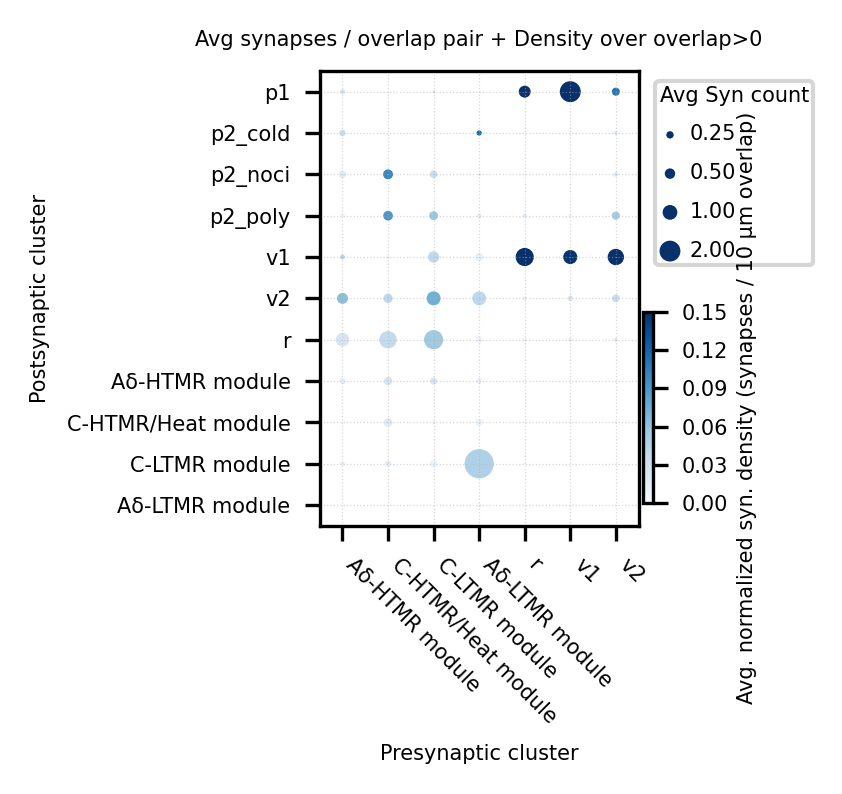

In [19]:
bubble_grid(
    size_df=A_overlappairs_avg,
    color_df=D_overlaponly_avg,
    pre_order=pre_order,
    post_order=post_order,
    title="Avg synapses / overlap pair + Density over overlap>0",
    cmap="Blues",
    max_diam_pts=7.0,
    fig_cm=(4, 5),
    color_cap_percentile=95,
    size_vmax=float(np.nanmax(A_overlappairs_avg.to_numpy())),
    size_legend_ticks_abs=[0.25, 0.5, 1, 2],
    pre_label_map=LABEL_MAP,
    post_label_map=LABEL_MAP,
    save_svg_path=OUT_DIR / "figure4f_celltype_bubble_grid.svg",
)

A_overlappairs_avg.to_csv(OUT_DIR / "celltype_avg_synapses_per_overlapping_pair.csv")
D_overlaponly_avg.to_csv(OUT_DIR / "celltype_mean_density_over_overlapping_pairs.csv")